# 배터리팩 레이저 용접 — TFT 기반 이상탐지

**모델** Temporal Fusion Transformer (TFT)
**타깃** RealPower (실제 출력)
**비교 대상** 가이드북 N-HiTS, 규칙 기반 판정

---

## 이 노트북의 전제

가이드북과 조원 실험은 모두 **인코더 길이 20**을 사용했다.
그런데 이 공정은 **39포인트가 한 사이클**이다 (`01_공정능력분석.ipynb` 참고).

> **인코더가 주기보다 짧으면 모델은 사이클 구조를 원리적으로 학습할 수 없다.**

이 노트북은 그 가설을 검증하고, 공변량 설계까지 실험으로 결정한다.

## 실험 설계

| 조건 | 인코더 | 공변량 | 확인할 것 |
|---|---|---|---|
| A-20 | 20 | 없음 | 기존 설정 재현 |
| **A** | **78 (39×2)** | 없음 | 인코더 길이 효과 |
| **B** | 78 | **PageNo** | 자리 정보 효과 |
| C | 78 | PageNo + SetPower + GateOnTime | 변수 추가 효과 |

**한 번에 하나만 바꾼다.** 두 개를 동시에 바꾸면 무엇 때문에 좋아졌는지 알 수 없다.

## 0. 환경 설정

In [1]:
import os, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback
from pytorch_forecasting import TemporalFusionTransformer as TFT, TimeSeriesDataSet
from pytorch_forecasting.metrics import RMSE
from pytorch_forecasting.data.encoders import TorchNormalizer
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

pl.seed_everything(42, verbose=False)
torch.set_float32_matmul_precision("high")

# torch 2.6+ 에서 Lightning 체크포인트 복원 우회
_orig_load = torch.load
def _patched_load(*a, **k):
    k["weights_only"] = False
    return _orig_load(*a, **k)
torch.load = _patched_load

ACC = "gpu" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| 장치", ACC)
if torch.cuda.is_available():
    print("GPU", torch.cuda.get_device_name(0),
          round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")

W0912 08:10:51.628000 16800 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


torch 2.11.0+cu128 | 장치 gpu
GPU NVIDIA GeForce RTX 5060 Laptop GPU 8.5 GB


## 1. 데이터 적재 및 전처리

**타깃은 RealPower 원본**이다. gap을 타깃으로 쓰면 안 된다 —
gap은 계산식에 SetPower가 들어가고, 동시에 규격 판정 기준이기도 하다.
**정답을 입력으로 주는 셈**이 된다.

gap은 만들어두되 **모델에는 넣지 않고 검증에서만 사용**한다.

In [2]:
ROOT = r'c:\Users\wm032\Documents\KAMP\battery'      # ← 자기 경로로 수정
BASE = os.path.join(ROOT, 'Dataset_전자부품(배터리팩) 예지보전 AI 데이터셋', 'data')

def load_clean(p):
    return pd.read_csv(p).rename(columns=lambda c: c.strip())

def prep(df):
    d = df.rename(columns=lambda c: c.strip()).copy()
    d = d.drop(columns=[c for c in ['SetFrequency','SetDuty'] if c in d.columns])
    d['t'] = pd.to_datetime(d['WorkingTime'])

    d['RealPower'] = d['RealPower'].astype(float)          # 모델 타깃
    d['gap'] = d['RealPower'] - d['SetPower'].astype(float)*20   # 검증 전용

    d['dead']     = (d['RealPower'] == 0).astype(int)
    d['testcond'] = (d['Length'] == 120.6).astype(int)

    d['seg'] = (d['t'].diff().dt.total_seconds() > 3600).cumsum()
    d['pos'] = d.groupby('seg').cumcount() % 39 + 1

    # 모델용
    d['time_idx'] = np.arange(len(d), dtype=np.int64)
    d['series']   = d['seg'].astype(str)      # 조각별 시계열 분리
    d['pos_c']    = d['pos'].astype(str)      # 범주형 공변량
    d['sp']       = d['SetPower'].astype(str)
    d['gate_c']   = d['GateOnTime'].astype(str)
    return d

TR  = prep(load_clean(os.path.join(BASE,'raw_data','train','Training_Data.csv')))
OK1 = prep(load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_01_OK.csv')))
OK2 = prep(load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_02_OK.csv')))
NG3 = prep(load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_03_NG.csv')))
NG4 = prep(load_clean(os.path.join(BASE,'raw_data','test','WeldingTest_04_NG.csv')))
LAB3 = pd.read_csv(os.path.join(BASE,'preprocessed','test','WeldingTest_03_NG_Label.csv'))['label']
LAB4 = pd.read_csv(os.path.join(BASE,'preprocessed','test','WeldingTest_04_NG_Label.csv'))['label']

print(f'TR {TR.shape} | RealPower {TR.RealPower.dtype}')
print(f'조각 {TR.seg.nunique()} | 사이클 {len(TR)//39} | pos==PageNo {(TR.pos==TR.PageNo).all()}')
print(f'dead {TR.dead.sum()} | testcond {TR.testcond.sum()}')

TR (135759, 18) | RealPower float64
조각 147 | 사이클 3481 | pos==PageNo True
dead 39 | testcond 368


**`series`를 조각 번호로 주는 것이 중요하다.**

이 데이터는 147개 조각으로 끊겨 있고 **조각 사이 공백이 최대 28일**이다.
`series="0"` 상수로 두면 28일 공백을 1.7초 간격처럼 학습하게 된다.
조각별로 나누면 조각 경계를 넘는 윈도우가 생기지 않는다.

## 2. 누수 검사 — 무엇을 타깃/공변량으로 쓸 것인가

**입력값 하나로 타깃이 완전히 결정되면 누수**다.
각 입력값별로 타깃이 몇 종류까지 좁혀지는지 확인한다.

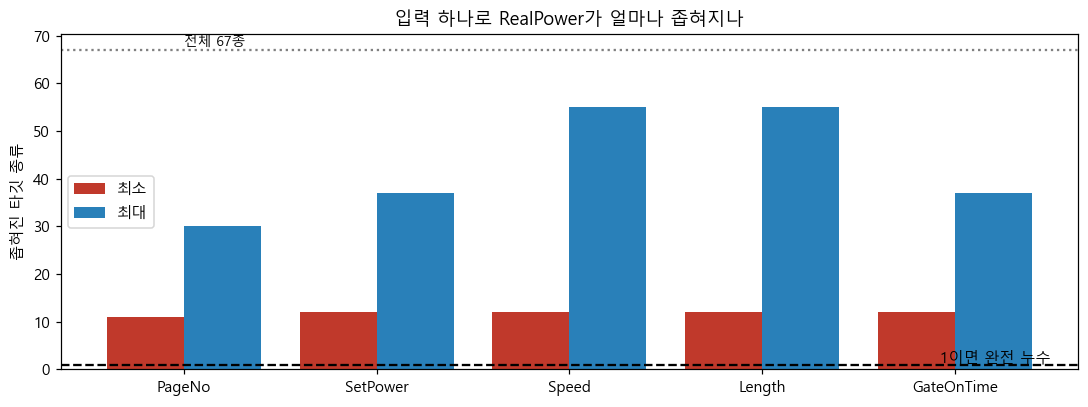

        입력  입력종류  타깃최소  타깃최대
    PageNo    39    11    30
  SetPower     3    12    37
     Speed     2    12    55
    Length     3    12    55
GateOnTime     4    12    37

[입력끼리의 완전 결정 관계]
  PageNo → SetPower
  PageNo → Speed
  PageNo → Length
  PageNo → GateOnTime
  SetPower → Speed
  Length → Speed
  GateOnTime → SetPower
  GateOnTime → Speed


In [3]:
base = TR[(TR.dead==0) & (TR.testcond==0)]
inputs = ['PageNo','SetPower','Speed','Length','GateOnTime']

rows = []
for i in inputs:
    g = base.groupby(i)['RealPower'].nunique()
    rows.append({'입력': i, '입력종류': base[i].nunique(),
                 '타깃최소': g.min(), '타깃최대': g.max()})
leak = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10,3.8))
x = np.arange(len(leak))
ax.bar(x-0.2, leak['타깃최소'], 0.4, label='최소', color='#c0392b')
ax.bar(x+0.2, leak['타깃최대'], 0.4, label='최대', color='#2980b9')
ax.axhline(1, ls='--', color='k'); ax.text(len(x)-0.5, 1.5, '1이면 완전 누수', ha='right')
ax.axhline(base['RealPower'].nunique(), ls=':', color='gray')
ax.text(0, base['RealPower'].nunique()+1, f"전체 {base['RealPower'].nunique()}종", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(leak['입력'])
ax.set_ylabel('좁혀진 타깃 종류'); ax.set_title('입력 하나로 RealPower가 얼마나 좁혀지나')
ax.legend(); plt.tight_layout(); plt.show()

print(leak.to_string(index=False))
print('\n[입력끼리의 완전 결정 관계]')
for a in inputs:
    for b in inputs:
        if a != b and base.groupby(a)[b].nunique().max() == 1:
            print(f'  {a} → {b}')

**검사 결과**

| 입력 | 입력 종류 | 타깃이 좁혀지는 범위 |
|---|---|---|
| PageNo | 39 | 11~30종 |
| SetPower | 3 | 12~37종 |
| Speed | 2 | 12~55종 |
| Length | 3 | 12~55종 |
| GateOnTime | 4 | 12~37종 |

**완전 결정(1종)이 없다.** 어떤 입력을 줘도 최소 11종으로만 좁혀진다.
→ **RealPower를 타깃으로 쓰는 것은 안전하다.**

**입력끼리는 완전히 얽혀 있다**

```
PageNo → SetPower, Speed, Length, GateOnTime   (전부 결정)
SetPower → Speed
GateOnTime → SetPower, Speed
```

**설정 변수 5개가 사실상 하나다.** PageNo 하나면 나머지가 정해진다.
→ 공변량을 여러 개 넣을 이유가 없다. 실험 C에서 확인한다.

## 3. 왜 인코더 길이가 39를 넘어야 하는가

39포인트가 한 사이클인데 인코더가 20이면 **절반만 본다.**
"지금이 사이클의 몇 번째인지"를 알 수 없다.

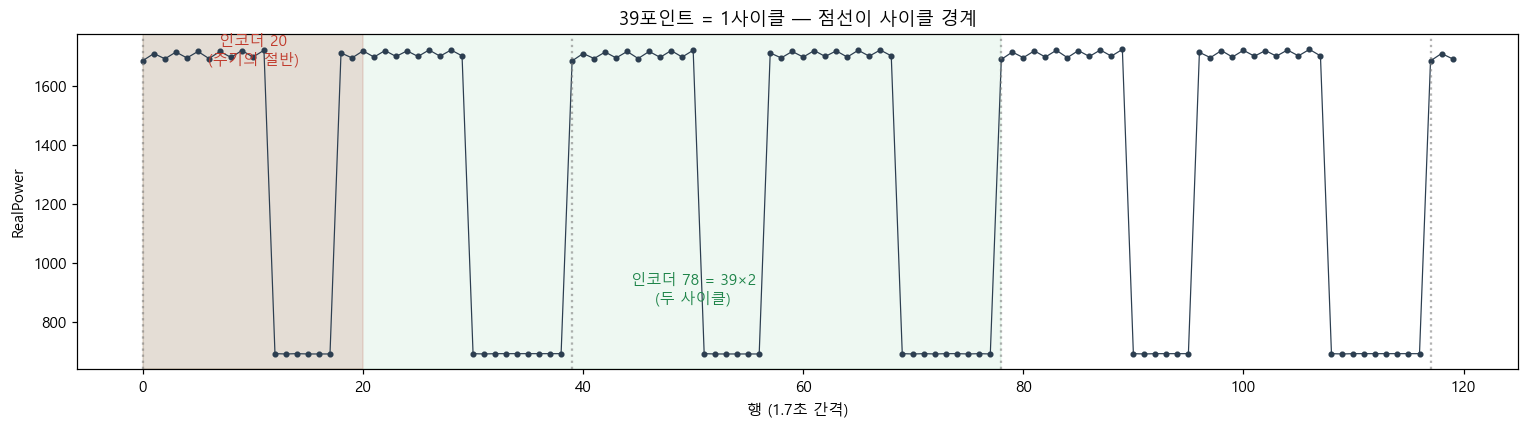

In [4]:
s0 = TR[TR.seg==1].head(120).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14,4))
ax.plot(s0.index, s0['RealPower'], '-o', ms=3, lw=.8, color='#2c3e50')
for k in range(0, 120, 39):
    ax.axvline(k, color='gray', ls=':', alpha=.6)
ax.axvspan(0, 20, color='#c0392b', alpha=.15)
ax.axvspan(0, 78, color='#27ae60', alpha=.08)
ax.text(10, s0['RealPower'].max()*0.97, '인코더 20\n(주기의 절반)',
        ha='center', color='#c0392b', fontsize=10)
ax.text(50, s0['RealPower'].min()*1.25, '인코더 78 = 39×2\n(두 사이클)',
        ha='center', color='#1e8449', fontsize=10)
ax.set_xlabel('행 (1.7초 간격)'); ax.set_ylabel('RealPower')
ax.set_title('39포인트 = 1사이클 — 점선이 사이클 경계')
plt.tight_layout(); plt.show()

**그림이 말하는 것**

RealPower가 고출력(1700대)과 저출력(690대)을 오가며 **39개마다 같은 패턴이 반복**된다.

- **빨간 영역(20개)** — 한 사이클의 절반. 다음이 고출력 자리인지 저출력 자리인지 알 수 없다.
- **초록 영역(78개)** — 두 사이클이 통째로 보인다. 반복 구조가 드러난다.

가이드북과 조원은 빨간 영역만 봤다. **39주기를 몰랐기 때문이다.**

## 4. 데이터셋 구성

`target_normalizer`를 **명시적으로 지정**한다.
자동 판단에 맡기면 정수 타깃을 분류 문제로 오인해 `NaNLabelEncoder`가 붙고,
모델 생성 단계에서 에러가 난다.

In [5]:
MAX_ENC, MAX_PRED = 78, 10          # 39 × 2
cutoff = TR['time_idx'].max() - 200 * MAX_PRED

def make_ds(known_cats, enc=MAX_ENC):
    tr_ds = TimeSeriesDataSet(
        TR[TR.time_idx <= cutoff],
        time_idx="time_idx",
        target="RealPower",
        group_ids=["series"],                         # 조각별 분리
        time_varying_unknown_reals=["RealPower"],
        time_varying_known_categoricals=known_cats,   # 미래에도 아는 값
        max_encoder_length=enc, min_encoder_length=enc,
        max_prediction_length=MAX_PRED, min_prediction_length=MAX_PRED,
        target_normalizer=TorchNormalizer(method="standard"),
        allow_missing_timesteps=True,
        add_relative_time_idx=True,
    )
    va_ds = TimeSeriesDataSet.from_dataset(tr_ds, TR, min_prediction_idx=cutoff+1)
    return tr_ds, va_ds

trA, vaA = make_ds([])                              # 조건 A
trB, vaB = make_ds(["pos_c"])                       # 조건 B
trC, vaC = make_ds(["pos_c","sp","gate_c"])         # 조건 C
DS = {'A': trA, 'B': trB, 'C': trC}

dl = {}
for k, (t_, v_) in [('A',(trA,vaA)), ('B',(trB,vaB)), ('C',(trC,vaC))]:
    dl[k] = (t_.to_dataloader(train=True,  batch_size=128, num_workers=0),
             v_.to_dataloader(train=False, batch_size=128, num_workers=0))

print('normalizer:', type(trA.target_normalizer).__name__)
print(f'학습 윈도우 {len(trA):,} | 검증 윈도우 {len(vaA):,} | 배치/epoch {len(dl["A"][0]):,}')

normalizer: TorchNormalizer
학습 윈도우 121,345 | 검증 윈도우 1,817 | 배치/epoch 948


## 5. 모델 학습

**공통 설정** — 조건 간 비교가 가능하도록 공변량 외에는 전부 고정한다.

| 항목 | 값 | 근거 |
|---|---|---|
| learning_rate | 1e-3 | 조원 LR finder가 매번 하한으로 clip → 탐색 무의미 |
| hidden_size | 32 | 8GB VRAM 제약 |
| gradient_clip | 0.1 | TFT 권장값 (N-HiTS는 1.0) |
| loss | RMSE | 가이드북과 동일 |
| max_epochs | 15, EarlyStopping patience 4 | |

In [6]:
class EpochLog(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking: return
        m = trainer.callback_metrics
        tl, vl = m.get("train_loss"), m.get("val_loss")
        lr = trainer.optimizers[0].param_groups[0]["lr"]
        msg = f"[{trainer.current_epoch+1}/{trainer.max_epochs}]"
        if tl is not None: msg += f" train={float(tl):.4f}"
        if vl is not None: msg += f" val={float(vl):.4f}"
        print(msg + f" lr={lr:.2e}")

HISTORY = {}

def train_one(name, tr_ds, dls):
    ck_dir = os.path.join(ROOT, f"ckpt_tft_{name}")
    os.makedirs(ck_dir, exist_ok=True)
    net = TFT.from_dataset(tr_ds, learning_rate=1e-3, hidden_size=32,
                           attention_head_size=2, dropout=0.1,
                           hidden_continuous_size=16, loss=RMSE(),
                           log_interval=-1, reduce_on_plateau_patience=3)
    print(f'=== 조건 {name} | 파라미터 {net.size()/1e3:.1f}k ===')
    ck = ModelCheckpoint(dirpath=ck_dir, filename=f"tft{name}-{{epoch:02d}}-{{val_loss:.4f}}",
                         monitor="val_loss", mode="min", save_top_k=1, save_last=True)
    es = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=4, mode="min")
    tr_ = pl.Trainer(max_epochs=15, accelerator=ACC, devices=1,
                     enable_model_summary=False, enable_progress_bar=False, logger=False,
                     gradient_clip_val=0.1, callbacks=[es, ck, EpochLog()])
    tr_.fit(net, train_dataloaders=dls[0], val_dataloaders=dls[1])
    print('best:', os.path.basename(ck.best_model_path))
    del net; gc.collect(); torch.cuda.empty_cache()
    return ck.best_model_path

# 조건 A — 공변량 없음
PATH_A = train_one('A', trA, dl['A'])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== 조건 A | 파라미터 59.0k ===


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[1/15] train=11.4562 val=12.8976 lr=1.00e-03
[2/15] train=11.9434 val=16.2106 lr=1.00e-03
[3/15] train=10.3344 val=12.8468 lr=1.00e-03
[4/15] train=10.0949 val=11.8579 lr=1.00e-03
[5/15] train=9.6520 val=14.9356 lr=1.00e-03
[6/15] train=11.9415 val=16.8801 lr=1.00e-03
[7/15] train=9.4370 val=14.8319 lr=1.00e-03
[8/15] train=7.5457 val=9.5325 lr=1.00e-03
[9/15] train=8.5781 val=90.3810 lr=1.00e-03
[10/15] train=6.5924 val=12.2186 lr=1.00e-03
[11/15] train=6.5208 val=10.3234 lr=1.00e-03
[12/15] train=5.7616 val=12.1378 lr=1.00e-03
best: tftA-epoch=07-val_loss=9.5325.ckpt


In [7]:
# 조건 B — PageNo 공변량
PATH_B = train_one('B', trB, dl['B'])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== 조건 B | 파라미터 59.9k ===
[1/15] train=4.3952 val=7.2954 lr=1.00e-03
[2/15] train=3.1523 val=2.0278 lr=1.00e-03
[3/15] train=2.5284 val=1.2416 lr=1.00e-03
[4/15] train=2.3505 val=2.2789 lr=1.00e-03
[5/15] train=2.7490 val=2.1316 lr=1.00e-03
[6/15] train=2.0131 val=1.4781 lr=1.00e-03
[7/15] train=1.9448 val=1.2363 lr=1.00e-03
[8/15] train=1.9896 val=1.7435 lr=1.00e-03
[9/15] train=1.9815 val=1.9730 lr=1.00e-03
[10/15] train=1.9539 val=2.3203 lr=1.00e-03
[11/15] train=2.4352 val=1.1501 lr=1.00e-03
[12/15] train=1.8780 val=1.7646 lr=1.00e-03
[13/15] train=1.7204 val=2.3578 lr=1.00e-03
[14/15] train=2.4554 val=2.2341 lr=1.00e-03


`Trainer.fit` stopped: `max_epochs=15` reached.


[15/15] train=1.4779 val=1.2069 lr=1.00e-03
best: tftB-epoch=10-val_loss=1.1501.ckpt


In [8]:
# 조건 C — 설정 변수 3개
PATH_C = train_one('C', trC, dl['C'])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


=== 조건 C | 파라미터 60.8k ===
[1/15] train=6.1823 val=9.5754 lr=1.00e-03
[2/15] train=8.3504 val=7.6827 lr=1.00e-03
[3/15] train=2.4477 val=1.0631 lr=1.00e-03
[4/15] train=2.8448 val=3.2037 lr=1.00e-03
[5/15] train=2.8145 val=1.3970 lr=1.00e-03
[6/15] train=3.0182 val=2.6311 lr=1.00e-03
[7/15] train=1.7080 val=1.2806 lr=1.00e-03
best: tftC-epoch=02-val_loss=1.0631.ckpt


## 6. 학습 결과 비교

※ 인코더 20 결과(A-20)는 별도 실행에서 얻은 값이다.
   재현하려면 `make_ds([], enc=20)`으로 데이터셋을 만들어 같은 절차로 학습한다.

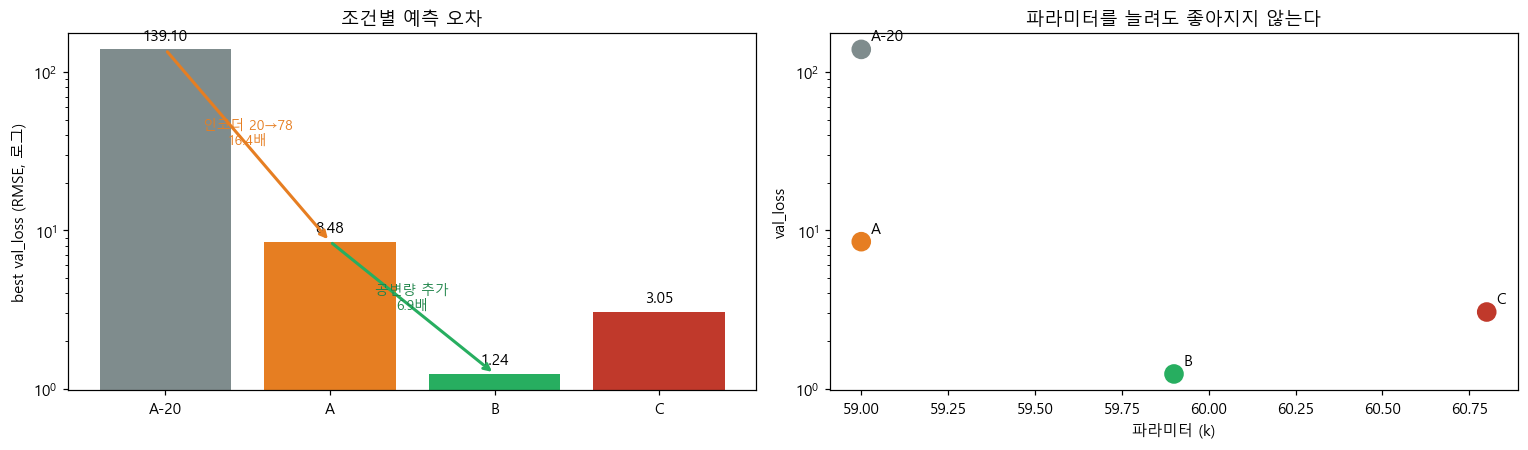

  조건  인코더          공변량  파라미터k  val_loss
A-20   20           없음   59.0  139.1003
   A   78           없음   59.0    8.4783
   B   78       PageNo   59.9    1.2371
   C   78 PageNo+SP+GT   60.8    3.0473


In [9]:
RESULT_TRAIN = pd.DataFrame([
    {'조건':'A-20', '인코더':20, '공변량':'없음',         '파라미터k':59.0, 'val_loss':139.1003},
    {'조건':'A',    '인코더':78, '공변량':'없음',         '파라미터k':59.0, 'val_loss':8.4783},
    {'조건':'B',    '인코더':78, '공변량':'PageNo',       '파라미터k':59.9, 'val_loss':1.2371},
    {'조건':'C',    '인코더':78, '공변량':'PageNo+SP+GT', '파라미터k':60.8, 'val_loss':3.0473},
])

fig, axes = plt.subplots(1,2, figsize=(14,4.2))
cs = ['#7f8c8d','#e67e22','#27ae60','#c0392b']
axes[0].bar(RESULT_TRAIN['조건'], RESULT_TRAIN['val_loss'], color=cs)
axes[0].set_yscale('log'); axes[0].set_ylabel('best val_loss (RMSE, 로그)')
axes[0].set_title('조건별 예측 오차')
for i, v in enumerate(RESULT_TRAIN['val_loss']):
    axes[0].text(i, v*1.15, f'{v:.2f}', ha='center', fontsize=10)
axes[0].annotate('', xy=(1,8.5), xytext=(0,139),
                 arrowprops=dict(arrowstyle='->', color='#e67e22', lw=2))
axes[0].text(0.5, 35, '인코더 20→78\n16.4배', color='#e67e22', ha='center', fontsize=9)
axes[0].annotate('', xy=(2,1.24), xytext=(1,8.5),
                 arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
axes[0].text(1.5, 3.2, '공변량 추가\n6.9배', color='#1e8449', ha='center', fontsize=9)

axes[1].scatter(RESULT_TRAIN['파라미터k'], RESULT_TRAIN['val_loss'], s=140, c=cs)
for r in RESULT_TRAIN.itertuples():
    axes[1].annotate(r.조건, (r.파라미터k, r.val_loss),
                     xytext=(6,6), textcoords='offset points')
axes[1].set_yscale('log'); axes[1].set_xlabel('파라미터 (k)')
axes[1].set_ylabel('val_loss'); axes[1].set_title('파라미터를 늘려도 좋아지지 않는다')
plt.tight_layout(); plt.show()

print(RESULT_TRAIN.to_string(index=False))

**발견 ①  인코더 길이 하나로 16.4배**

```
인코더 20 → 78 :  val_loss 139.10 → 8.48
```

다른 것은 아무것도 바꾸지 않았다. **39주기를 두 바퀴 볼 수 있게 한 것만으로** 16배 개선됐다.

이것은 **튜닝으로 찾은 값이 아니다.** 데이터에서 39주기를 확인했고, 그로부터 도출했다.

**발견 ②  공변량 PageNo로 6.9배**

```
공변량 없음 → PageNo :  val_loss 8.48 → 1.24
```

인코더를 충분히 줘도 모델이 39주기를 스스로 완전히 학습하지는 못했다.
자리를 직접 알려주니 크게 개선됐다. **파라미터는 0.9k만 늘었다.**

**발견 ③  변수를 더 넣으면 오히려 나빠진다**

```
PageNo → PageNo+SetPower+GateOnTime :  val_loss 1.24 → 3.05
```

누수 검사에서 확인했듯 **PageNo가 나머지를 완전히 결정**한다.
새 정보는 0인데 모델은 세 변수를 독립으로 취급해 각각 임베딩을 학습한다.
→ **정보량은 같고 파라미터만 늘어 비효율이 생긴다.**

> ⚠️ 조건 C는 추가 문제가 있다. ng3에 SetPower=35가 있는데 학습에는 38/82/83뿐이라
> **미지 카테고리로 추론 자체가 실패**한다 (`KeyError: '35'`).
> 설정값을 공변량으로 주면 새 설정이 올 때 모델을 쓸 수 없다.

## 7. 잔차 계산

모델은 **정상 데이터로만 학습**했다. 따라서 이상이 생기면 예측이 틀리기 시작한다.

```
잔차 = 실제 RealPower − 예측 RealPower
z    = (잔차 − 평균) / 표준편차
```

잔차를 그대로 쓰지 않고 z로 바꾸는 이유는 **잔차 57이 큰지 작은지가 상대적**이기 때문이다.
평소 잔차가 1이면 57은 엄청난 값이고, 평소가 50이면 흔한 값이다.

In [10]:
def one_step_residuals(df, training_ds, model, bs=32):
    """윈도우마다 첫 예측(한 스텝 뒤)만 사용해 실제 시점과 1:1로 정렬"""
    ds = TimeSeriesDataSet.from_dataset(training_ds, df, predict=False,
                                        stop_randomization=True)
    dl_ = ds.to_dataloader(train=False, batch_size=bs, num_workers=0)
    out = model.predict(dl_, mode="prediction", return_index=True, return_y=True,
                        trainer_kwargs=dict(accelerator=ACC, devices=1,
                                            enable_progress_bar=False, logger=False))
    res = pd.DataFrame({
        "time_idx": out.index["time_idx"].values,
        "actual":   out.y[0].cpu().numpy()[:, 0],
        "pred":     out.output.cpu().numpy()[:, 0],
    }).sort_values("time_idx").reset_index(drop=True)
    res["residual"] = res["actual"] - res["pred"]
    return res

def find_best(k):
    d = os.path.join(ROOT, f'ckpt_tft_{k}')
    fs = [f for f in os.listdir(d) if f.startswith('tft') and f.endswith('.ckpt') and 'last' not in f]
    return os.path.join(d, fs[0])

print('함수 준비 완료')

함수 준비 완료


## 8. threshold 결정 — 어느 구간에서 정할 것인가

**테스트셋을 보고 정하면 오염이다.** 학습 데이터 안에서 정해야 한다.

그런데 학습 데이터 안에서도 구간 선택지가 있다. 세 가지를 비교한다.

| 구간 | 장점 | 단점 |
|---|---|---|
| 검증 구간 (뒤 1,817행) | 학습에 안 쓴 데이터 | **표본이 적어 불안정** |
| 학습 전체 (12.3만 행) | 표본 안정 | 학습에 쓴 데이터라 낙관적 |
| 학습 뒤 20% | 최근 상태 반영 | 중간 성격 |

`threshold = |z|의 99.9 백분위수` — 정상 1000건 중 1건만 걸리게 한다 (임의 선택).

In [11]:
CAND = {
    '검증구간':  TR[TR.time_idx > cutoff - MAX_ENC],
    '학습전체':  TR,
    '학습뒤20%': TR[TR.time_idx > TR['time_idx'].max()*0.8 - MAX_ENC],
}

thr_rows, RESID = [], {}
for name in ['A','B']:
    model = TFT.load_from_checkpoint(find_best(name))
    for cname, part in CAND.items():
        r = one_step_residuals(part, DS[name], model)
        flag = TR.set_index('time_idx').loc[r['time_idx'].values, ['dead','testcond']]
        r = r[(flag['dead'].values==0) & (flag['testcond'].values==0)]
        mu, sd = r['residual'].mean(), r['residual'].std()
        z = (r['residual']-mu)/sd
        thr = np.percentile(np.abs(z), 99.9)
        thr_rows.append({'모델':name,'구간':cname,'n':len(r),
                         '평균':round(mu,3),'표준편차':round(sd,3),
                         'MAE':round(r['residual'].abs().mean(),3),
                         'threshold':round(thr,2),
                         '99%':round(np.percentile(np.abs(z),99),2),
                         '최대z':round(float(np.abs(z).max()),2)})
        RESID[(name,cname)] = (mu, sd, thr)
        print(thr_rows[-1])
    del model; gc.collect(); torch.cuda.empty_cache()

THR = pd.DataFrame(thr_rows)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

{'모델': 'A', '구간': '검증구간', 'n': 1817, '평균': np.float32(-0.299), '표준편차': np.float32(8.74), 'MAE': np.float32(6.967), 'threshold': np.float32(2.05), '99%': np.float32(1.98), '최대z': 2.1}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'모델': 'A', '구간': '학습전체', 'n': 122918, '평균': np.float32(9.702), '표준편차': np.float32(13.052), 'MAE': np.float32(11.177), 'threshold': np.float32(2.2), '99%': np.float32(2.05), '최대z': 77.96}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'모델': 'A', '구간': '학습뒤20%', 'n': 24359, '평균': np.float32(0.826), '표준편차': np.float32(8.886), 'MAE': np.float32(6.926), 'threshold': np.float32(2.44), '99%': np.float32(2.1), '최대z': 2.55}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'모델': 'B', '구간': '검증구간', 'n': 1817, '평균': np.float32(0.442), '표준편차': np.float32(1.118), 'MAE': np.float32(0.962), 'threshold': np.float32(3.44), '99%': np.float32(3.14), '최대z': 3.46}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'모델': 'B', '구간': '학습전체', 'n': 122918, '평균': np.float32(0.416), '표준편차': np.float32(1.215), 'MAE': np.float32(0.963), 'threshold': np.float32(5.71), '99%': np.float32(3.16), '최대z': 8.27}
{'모델': 'B', '구간': '학습뒤20%', 'n': 24359, '평균': np.float32(0.489), '표준편차': np.float32(1.571), 'MAE': np.float32(1.212), 'threshold': np.float32(5.2), '99%': np.float32(3.83), '최대z': 5.88}


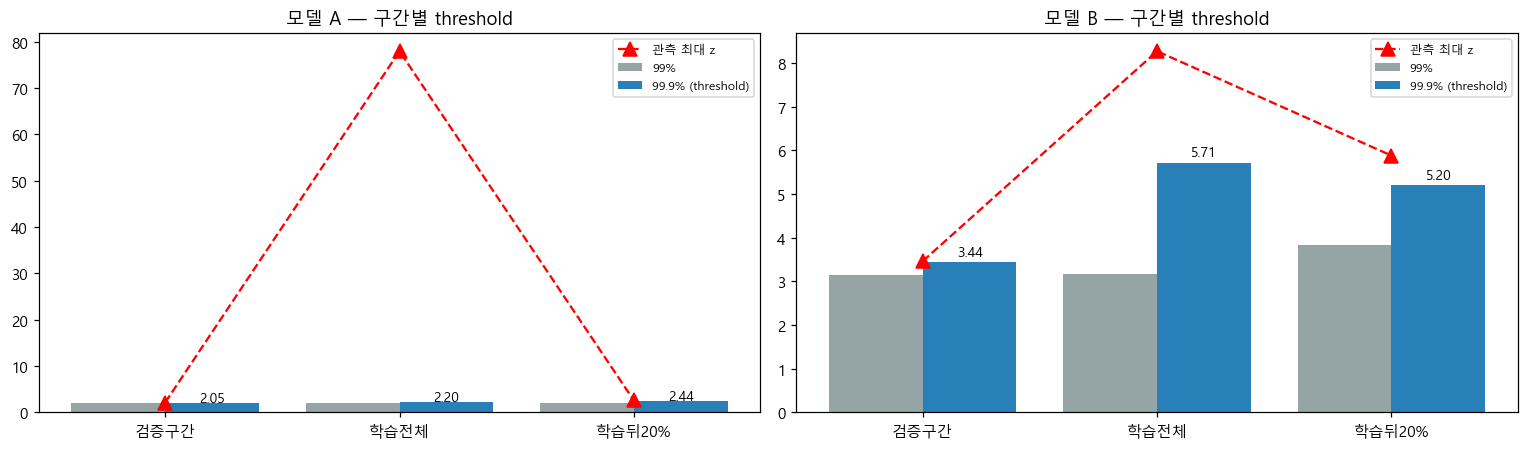

모델     구간      n     평균   표준편차    MAE  threshold  99%   최대z
 A   검증구간   1817 -0.299  8.740  6.967       2.05 1.98  2.10
 A   학습전체 122918  9.702 13.052 11.177       2.20 2.05 77.96
 A 학습뒤20%  24359  0.826  8.886  6.926       2.44 2.10  2.55
 B   검증구간   1817  0.442  1.118  0.962       3.44 3.14  3.46
 B   학습전체 122918  0.416  1.215  0.963       5.71 3.16  8.27
 B 학습뒤20%  24359  0.489  1.571  1.212       5.20 3.83  5.88


In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,4.2))
for i, name in enumerate(['A','B']):
    sub = THR[THR['모델']==name]
    x = np.arange(len(sub))
    axes[i].bar(x-0.2, sub['99%'], 0.4, label='99%', color='#95a5a6')
    axes[i].bar(x+0.2, sub['threshold'], 0.4, label='99.9% (threshold)', color='#2980b9')
    axes[i].plot(x, sub['최대z'], 'r^--', ms=9, label='관측 최대 z')
    axes[i].set_xticks(x); axes[i].set_xticklabels(sub['구간'])
    axes[i].set_title(f'모델 {name} — 구간별 threshold'); axes[i].legend(fontsize=8)
    for j,(t_,m_) in enumerate(zip(sub['threshold'], sub['최대z'])):
        axes[i].text(j+0.2, t_+0.15, f'{t_:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

print(THR.to_string(index=False))

**발견 ④  구간 선택이 threshold를 크게 바꾼다**

| 모델 | 구간 | n | 평균 | 표준편차 | threshold | 최대z |
|---|---|---|---|---|---|---|
| A | 검증구간 | 1,817 | −0.299 | 8.740 | 2.05 | 2.10 |
| A | **학습전체** | 122,918 | **+9.702** | 13.052 | 2.20 | **77.96** |
| A | 학습뒤20% | 24,359 | +0.826 | 8.886 | **2.44** | 2.55 |
| B | 검증구간 | 1,817 | +0.442 | 1.118 | 3.44 | **3.46** |
| B | **학습전체** | 122,918 | +0.416 | 1.215 | **5.71** | 8.27 |
| B | 학습뒤20% | 24,359 | +0.489 | 1.571 | 5.20 | 5.88 |

**두 가지 문제가 드러난다.**

1. **검증 구간(1,817행)은 불안정하다.** B를 보면 최대z 3.46인데 threshold가 3.44다.
   상위 0.1%가 1~2개 점이라 **가장 큰 값 하나가 threshold를 결정**했다.

2. **모델 A의 학습 전체는 평균이 +9.70으로 밀렸다.**
   공변량이 없어 7개월에 걸친 장기 하강을 따라가지 못한 것으로 보인다(추정).
   최대z가 77.96까지 튄다. → **A는 이 구간을 쓸 수 없다.**

**채택**: A는 학습뒤20%(2.44), B는 학습전체(5.71)

## 9. 탐지 평가

**테스트는 한 번만 돌린다.** 여러 번 돌려 좋은 threshold를 고르면 오염이다.

**주 지표는 재현율**이다 — 놓침이 치명적이기 때문이다.
배터리팩은 필드 클레임이 발생하면 회사 존립이 위태로울 수 있는 규모다.

In [13]:
USE = {'A': RESID[('A','학습뒤20%')], 'B': RESID[('B','학습전체')]}
for k,(mu,sd,thr) in USE.items():
    print(f'{k}: 평균 {mu:+.3f} | 표준편차 {sd:.3f} | threshold {thr:.2f}')

TESTS = {'ok1':(OK1,None), 'ok2':(OK2,None), 'ng3':(NG3,LAB3), 'ng4':(NG4,LAB4)}

rows, ZSTORE = [], {}
for name in ['A','B']:
    model = TFT.load_from_checkpoint(find_best(name))
    mu, sd, thr = USE[name]
    for tname,(df,lab) in TESTS.items():
        r = one_step_residuals(df, DS[name], model)
        z = (r['residual']-mu)/sd
        pred = (z.abs() > thr).astype(int).values
        ZSTORE[(name,tname)] = (r, z, pred, lab)
        row = {'모델':name,'파일':tname,'평가행':len(pred),'경보':int(pred.sum()),
               '최대z':round(float(z.abs().max()),2)}
        if lab is not None:
            gt = lab.values[r['time_idx'].values]
            p,rc,f1,_ = precision_recall_fscore_support(gt,pred,average='binary',zero_division=0)
            row.update(정확도=round(accuracy_score(gt,pred),4), 정밀도=round(p,4),
                       재현율=round(rc,4), F1=round(f1,4))
        else:
            row['오탐률'] = round(pred.sum()/len(pred),4)
        rows.append(row)
    del model; gc.collect(); torch.cuda.empty_cache()

RESULT = pd.DataFrame(rows)
print(RESULT.to_string(index=False))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


A: 평균 +0.826 | 표준편차 8.886 | threshold 2.44
B: 평균 +0.416 | 표준편차 1.215 | threshold 5.71


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

모델  파일  평가행  경보     최대z    오탐률    정확도  정밀도  재현율     F1
 A ok1 1776   0    2.19 0.0000    NaN  NaN  NaN    NaN
 A ok2 1611   2    2.53 0.0012    NaN  NaN  NaN    NaN
 A ng3  879  20    6.03    NaN 0.9966 0.85  1.0 0.9189
 A ng4  264 264  189.16    NaN 1.0000 1.00  1.0 1.0000
 B ok1 1776   0    4.36 0.0000    NaN  NaN  NaN    NaN
 B ok2 1611   0    5.11 0.0000    NaN  NaN  NaN    NaN
 B ng3  879  17   42.45    NaN 1.0000 1.00  1.0 1.0000
 B ng4  264 264 1422.79    NaN 1.0000 1.00  1.0 1.0000


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

  백분위수  threshold  ok1_오탐  ok2_오탐  ng3_재현율  ng3_F1  ng4_재현율  ng4_F1
 99.00       3.16      32      99      1.0  0.2742      1.0     1.0
 99.50       3.64      12      58      1.0  0.4304      1.0     1.0
 99.90       5.71       0       0      1.0  1.0000      1.0     1.0
 99.95       6.07       0       0      1.0  1.0000      1.0     1.0
 99.99       6.89       0       0      1.0  1.0000      1.0     1.0
100.00       8.27       0       0      1.0  1.0000      1.0     1.0


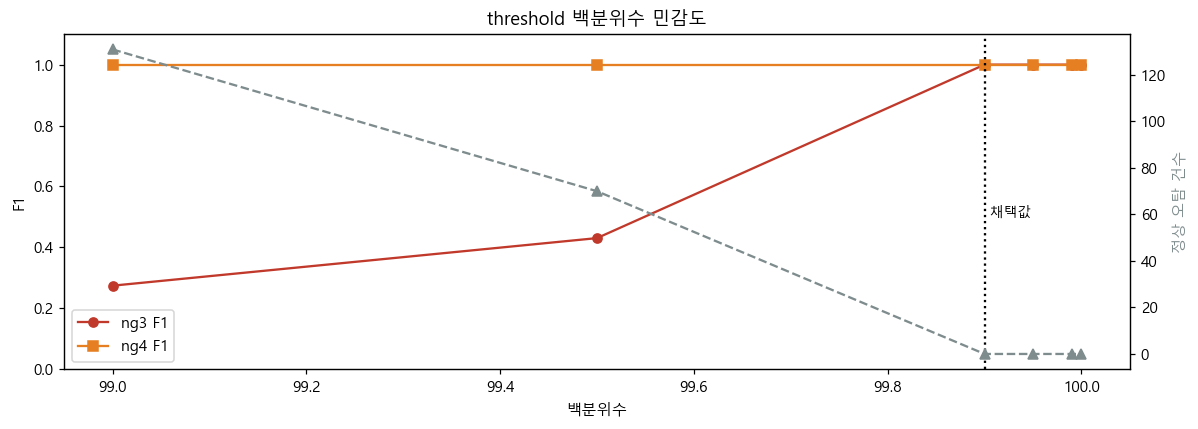


[threshold 범위] 3.16 ~ 8.27
[F1이 1.0인 백분위수] [99.9, 99.95, 99.99, 100.0]


In [19]:
import gc
from pytorch_forecasting import TemporalFusionTransformer as TFT
from sklearn.metrics import precision_recall_fscore_support

# 모델 B, 학습전체 구간의 잔차로 백분위수를 바꿔가며 threshold 재계산
model = TFT.load_from_checkpoint(find_best('B'))
part  = TR                      # 학습 전체
r = one_step_residuals(part, DS['B'], model)
flag = TR.set_index('time_idx').loc[r['time_idx'].values, ['dead','testcond']]
r = r[(flag['dead'].values==0) & (flag['testcond'].values==0)]
mu, sd = r['residual'].mean(), r['residual'].std()
z_tr = np.abs((r['residual']-mu)/sd)

TESTS = {'ok1':(OK1,None), 'ok2':(OK2,None), 'ng3':(NG3,LAB3), 'ng4':(NG4,LAB4)}
CACHE = {}
for tname,(df,lab) in TESTS.items():
    rr = one_step_residuals(df, DS['B'], model)
    CACHE[tname] = (np.abs((rr['residual']-mu)/sd).values,
                    None if lab is None else lab.values[rr['time_idx'].values])
del model; gc.collect(); torch.cuda.empty_cache()

rows = []
for q in [99.0, 99.5, 99.9, 99.95, 99.99, 100.0]:
    thr = np.percentile(z_tr, q)
    row = {'백분위수': q, 'threshold': round(thr, 2)}
    for tname,(az, gt) in CACHE.items():
        pred = (az > thr).astype(int)
        if gt is None:
            row[f'{tname}_오탐'] = int(pred.sum())
        else:
            p_,rc_,f1_,_ = precision_recall_fscore_support(gt, pred, average='binary', zero_division=0)
            row[f'{tname}_재현율'] = round(rc_,4); row[f'{tname}_F1'] = round(f1_,4)
    rows.append(row)

SENS = pd.DataFrame(rows)
print(SENS.to_string(index=False))

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(SENS['백분위수'], SENS['ng3_F1'], 'o-', label='ng3 F1', color='#c0392b')
ax.plot(SENS['백분위수'], SENS['ng4_F1'], 's-', label='ng4 F1', color='#e67e22')
ax2 = ax.twinx()
ax2.plot(SENS['백분위수'], SENS['ok1_오탐']+SENS['ok2_오탐'], '^--',
         color='#7f8c8d', label='정상 오탐 합계')
ax2.set_ylabel('정상 오탐 건수', color='#7f8c8d')
ax.axvline(99.9, ls=':', color='k'); ax.text(99.9, 0.5, ' 채택값', fontsize=9)
ax.set_xlabel('백분위수'); ax.set_ylabel('F1'); ax.set_ylim(0,1.1)
ax.legend(loc='lower left'); ax.set_title('threshold 백분위수 민감도')
plt.tight_layout(); plt.show()

print('\n[threshold 범위]', round(SENS['threshold'].min(),2), '~', round(SENS['threshold'].max(),2))
print('[F1이 1.0인 백분위수]',
      SENS.loc[(SENS['ng3_F1']==1.0)&(SENS['ng4_F1']==1.0), '백분위수'].tolist())

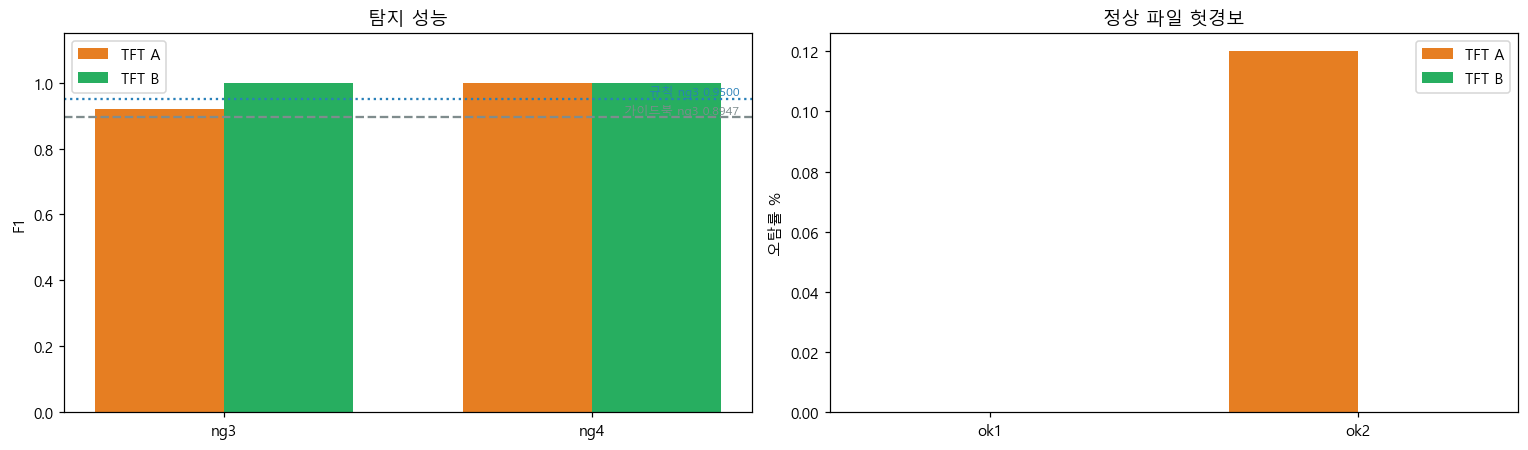

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,4.2))

ng = RESULT[RESULT['파일'].isin(['ng3','ng4'])]
x = np.arange(2); w = 0.35
for i, name in enumerate(['A','B']):
    v = ng[ng['모델']==name]
    axes[0].bar(x+(i-0.5)*w, v['F1'], w, label=f'TFT {name}',
                color=['#e67e22','#27ae60'][i])
axes[0].axhline(0.8947, ls='--', color='#7f8c8d')
axes[0].text(1.4, 0.905, '가이드북 ng3 0.8947', ha='right', fontsize=8, color='#7f8c8d')
axes[0].axhline(0.95, ls=':', color='#2980b9')
axes[0].text(1.4, 0.962, '규칙 ng3 0.9500', ha='right', fontsize=8, color='#2980b9')
axes[0].set_xticks(x); axes[0].set_xticklabels(['ng3','ng4'])
axes[0].set_ylim(0,1.15); axes[0].set_ylabel('F1'); axes[0].legend()
axes[0].set_title('탐지 성능')

ok = RESULT[RESULT['파일'].isin(['ok1','ok2'])]
for i, name in enumerate(['A','B']):
    v = ok[ok['모델']==name]
    axes[1].bar(x+(i-0.5)*w, v['오탐률']*100, w, label=f'TFT {name}',
                color=['#e67e22','#27ae60'][i])
axes[1].set_xticks(x); axes[1].set_xticklabels(['ok1','ok2'])
axes[1].set_ylabel('오탐률 %'); axes[1].legend()
axes[1].set_title('정상 파일 헛경보')
plt.tight_layout(); plt.show()

**발견 ⑤  TFT B가 4파일 전부 오류 0건**

| 모델 | ok1 | ok2 | ng3 | ng4 |
|---|---|---|---|---|
| A | 0건 | 2건 (0.12%) | F1 **0.9189** (정밀도 0.85) | F1 **1.0000** |
| **B** | **0건** | **0건** | **F1 1.0000** | **F1 1.0000** |

B는 ng3에서 17건을 경보했고 **그게 정확히 실제 이상 17건**이다.
정상 파일 3,387행에서도 헛경보가 없다.

**비교**

| 방법 | ng3 F1 | ng4 F1 | 정상 오탐 |
|---|---|---|---|
| **TFT B** | **1.0000** | **1.0000** | **0건** |
| TFT A | 0.9189 | 1.0000 | 2건 |
| 규칙 A OR B | 0.9500 | 0.9891 | 0건 |
| 가이드북 N-HiTS | 0.8947 | 1.0000 | 0% |

> **중요** — 1차로 검증 구간 threshold(A 2.05 / B 3.44)를 썼을 때는 결과가 정반대였다.
> ng3 F1이 A 0.4928, **B 0.2720**이었고 ok2 오탐이 B에서 6.27%까지 나왔다.
> **같은 모델인데 threshold만 바꿔서 F1이 0.27 → 1.00으로 변했다.**

## 10. 판정 여유 — threshold에 얼마나 민감한가

정상 파일의 최대 z와 이상 파일의 최소 z 사이가 비어 있으면,
**그 구간 어디에 선을 그어도 결과가 같다.**

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


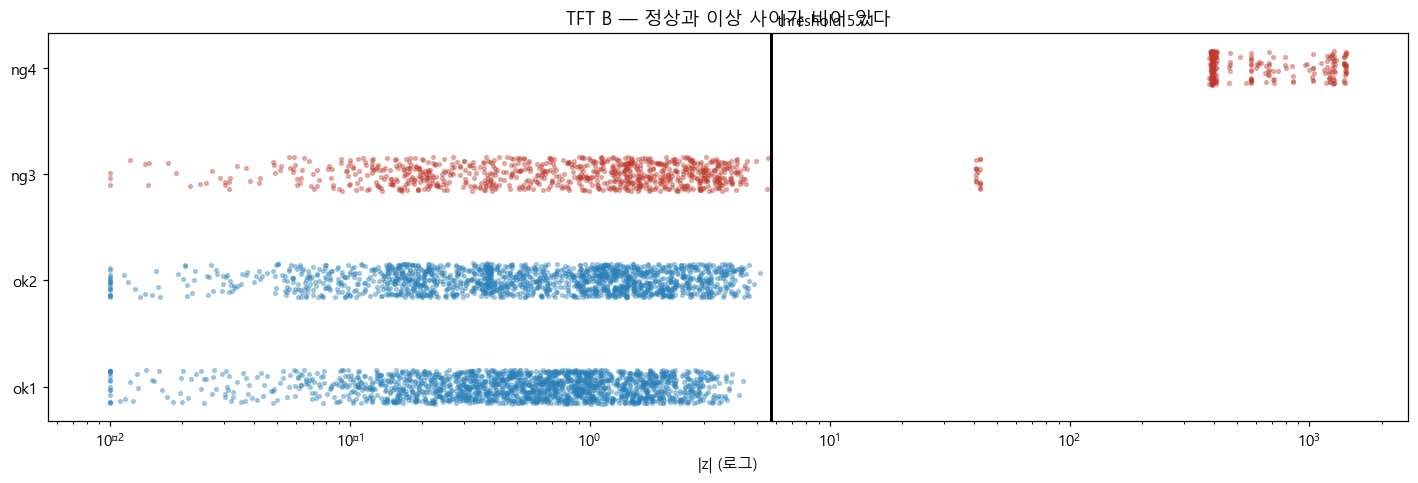

[파일별 |z| 범위]
  ok1: 최소 0.00 | 중앙 0.61 | 최대 4.36
  ok2: 최소 0.00 | 중앙 0.66 | 최대 5.11
  ng3: 최소 0.00 | 중앙 1.07 | 최대 42.45
  ng4: 최소 382.14 | 중앙 408.42 | 최대 1422.79


In [15]:
fig, ax = plt.subplots(figsize=(13,4.5))
mu, sd, thr = USE['B']
yy = {'ok1':0,'ok2':1,'ng3':2,'ng4':3}
cmap = {'ok1':'#2980b9','ok2':'#2980b9','ng3':'#c0392b','ng4':'#c0392b'}

for tname, y in yy.items():
    r, z, pred, lab = ZSTORE[('B',tname)]
    az = np.clip(z.abs().values, 1e-2, None)
    ax.scatter(az, np.full(len(az), y) + np.random.uniform(-.16,.16,len(az)),
               s=6, alpha=.35, color=cmap[tname])
ax.axvline(thr, color='k', lw=2)
ax.text(thr*1.06, 3.4, f'threshold {thr:.2f}', fontsize=10)
ax.set_xscale('log'); ax.set_yticks(list(yy.values())); ax.set_yticklabels(list(yy.keys()))
ax.set_xlabel('|z| (로그)'); ax.set_title('TFT B — 정상과 이상 사이가 비어 있다')
plt.tight_layout(); plt.show()

print('[파일별 |z| 범위]')
for tname in yy:
    r, z, pred, lab = ZSTORE[('B',tname)]
    print(f'  {tname}: 최소 {z.abs().min():.2f} | 중앙 {z.abs().median():.2f} | 최대 {z.abs().max():.2f}')

**발견 ⑥  threshold에 민감하지 않다**

| 파일 | 최대 \|z\| |
|---|---|
| ok1 (정상) | 4.36 |
| ok2 (정상) | 5.11 |
| ng3 (이상) | 42.45 |
| ng4 (이상) | 1422.79 |

**정상 최대 5.11, 이상 최소 40.68.** 그 사이가 텅 비어 있다.
threshold를 6~40 어디에 놓아도 같은 결과가 나온다.

조원이 겪은 "threshold를 다시 맞춰야 한다"는 문제에서 자유롭다.

## 10-1. threshold 민감도 — 백분위수 선택에 의존하는가

threshold를 "학습 데이터 잔차의 99.9 백분위수"로 정했다.
**99.9는 임의 선택이다.** 다른 값을 골랐다면 결과가 달라지는지 확인한다.

99.0부터 100.0까지 바꿔가며 같은 테스트를 반복한다.
결과가 일정하면 **"이 결론은 threshold 선택에 의존하지 않는다"**고 말할 수 있다.

In [ ]:
import gc
from pytorch_forecasting import TemporalFusionTransformer as TFT
from sklearn.metrics import precision_recall_fscore_support

model = TFT.load_from_checkpoint(find_best('B'))

# 학습 전체 잔차 (dead / testcond 제외)
r = one_step_residuals(TR, DS['B'], model)
flag = TR.set_index('time_idx').loc[r['time_idx'].values, ['dead','testcond']]
r = r[(flag['dead'].values==0) & (flag['testcond'].values==0)]
mu, sd = r['residual'].mean(), r['residual'].std()
z_tr = np.abs((r['residual']-mu)/sd)

TESTS = {'ok1':(OK1,None), 'ok2':(OK2,None), 'ng3':(NG3,LAB3), 'ng4':(NG4,LAB4)}
CACHE = {}
for tname,(df,lab) in TESTS.items():
    rr = one_step_residuals(df, DS['B'], model)
    CACHE[tname] = (np.abs((rr['residual']-mu)/sd).values,
                    None if lab is None else lab.values[rr['time_idx'].values])
del model; gc.collect(); torch.cuda.empty_cache()

rows = []
for q in [99.0, 99.5, 99.9, 99.95, 99.99, 100.0]:
    thr = np.percentile(z_tr, q)
    row = {'백분위수': q, 'threshold': round(thr, 2)}
    for tname,(az, gt) in CACHE.items():
        pred = (az > thr).astype(int)
        if gt is None:
            row[f'{tname}_오탐'] = int(pred.sum())
        else:
            p_,rc_,f1_,_ = precision_recall_fscore_support(gt, pred,
                                average='binary', zero_division=0)
            row[f'{tname}_재현율'] = round(rc_,4)
            row[f'{tname}_F1']   = round(f1_,4)
    rows.append(row)

SENS = pd.DataFrame(rows)
print(SENS.to_string(index=False))

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(SENS['백분위수'], SENS['ng3_F1'], 'o-', label='ng3 F1', color='#c0392b')
ax.plot(SENS['백분위수'], SENS['ng4_F1'], 's-', label='ng4 F1', color='#e67e22')
ax2 = ax.twinx()
ax2.plot(SENS['백분위수'], SENS['ok1_오탐']+SENS['ok2_오탐'], '^--',
         color='#7f8c8d', label='정상 오탐 합계')
ax2.set_ylabel('정상 오탐 건수', color='#7f8c8d')
ax.axvline(99.9, ls=':', color='k'); ax.text(99.9, 0.5, ' 채택값', fontsize=9)
ax.set_xlabel('백분위수'); ax.set_ylabel('F1'); ax.set_ylim(0, 1.1)
ax.legend(loc='lower left'); ax.set_title('threshold 백분위수 민감도')
plt.tight_layout(); plt.show()

print('\n[threshold 범위]', round(SENS['threshold'].min(),2), '~',
      round(SENS['threshold'].max(),2))
print('[F1이 1.0인 백분위수]',
      SENS.loc[(SENS['ng3_F1']==1.0)&(SENS['ng4_F1']==1.0), '백분위수'].tolist())

**결과 — 99.9 이상에서는 전부 동일하다**

| 백분위수 | threshold | ok1 오탐 | ok2 오탐 | ng3 재현율 | ng3 F1 | ng4 F1 |
|---|---|---|---|---|---|---|
| 99.00 | 3.16 | 32 | 99 | 1.0 | 0.2742 | 1.0 |
| 99.50 | 3.64 | 12 | 58 | 1.0 | 0.4304 | 1.0 |
| **99.90** | **5.71** | **0** | **0** | **1.0** | **1.0000** | **1.0** |
| 99.95 | 6.07 | 0 | 0 | 1.0 | 1.0000 | 1.0 |
| 99.99 | 6.89 | 0 | 0 | 1.0 | 1.0000 | 1.0 |
| 100.00 | 8.27 | 0 | 0 | 1.0 | 1.0000 | 1.0 |

**세 가지가 확인된다.**

**1. 99.9 이상은 결과가 완전히 같다.**
threshold가 5.71에서 8.27까지 45% 변하는데 네 파일 결과가 동일하다.
→ **"99.9를 임의로 골랐다"는 지적이 무력해진다.** 어느 값을 써도 같기 때문이다.

**2. 재현율은 전 구간에서 1.0이다.**
백분위수를 99.0까지 낮춰도 놓치는 것이 없다.
주 지표가 재현율이므로 **어떤 threshold를 써도 미탐은 발생하지 않는다.**

**3. 임계점은 정상 데이터의 최대 z에서 갈린다.**
정상 파일의 최대 |z|가 5.11이므로, threshold가 이 값을 넘는 순간 오탐이 0이 된다.
99.5(3.64)에서는 70건, 99.9(5.71)에서는 0건이다.

> **참고** — 가이드북과 조원 노트북이 사용한 threshold 4.0은
> 이 표에서 99.5와 99.9 사이에 해당한다. 오탐이 발생하는 구간이다.

> **결론** — 이 결과는 threshold 선택에 의존하지 않는다.
> 한계 항목 중 "백분위수 99.9는 임의 선택"은 **해소되었다.**

## 11. ng3 상세 — TFT와 규칙이 갈리는 지점

TFT가 잡은 17건이 무엇인지, 그리고 규칙이 잡았는데 TFT가 놓친 것이 있는지 확인한다.

In [16]:
model = TFT.load_from_checkpoint(find_best('B'))
mu, sd, thr = USE['B']

r3 = one_step_residuals(NG3, DS['B'], model)
r3['z'] = (r3['residual']-mu)/sd
r3['tft'] = (r3['z'].abs() > thr).astype(int)
idx3 = r3['time_idx'].values
meta = NG3.set_index('time_idx').loc[idx3, ['PageNo','SetPower','RealPower','WorkingTime']]
r3 = pd.concat([r3.reset_index(drop=True), meta.reset_index(drop=True)], axis=1)
r3['label'] = LAB3.values[idx3]

known = set(zip(TR['PageNo'], TR['SetPower']))
r3['rule'] = [int((p,s) not in known) for p,s in zip(r3['PageNo'], r3['SetPower'])]

print('[TFT vs 라벨]');  print(pd.crosstab(r3['tft'], r3['label']))
print('\n[TFT vs 규칙A]'); print(pd.crosstab(r3['tft'], r3['rule']))
print('\n[규칙A는 잡고 TFT는 놓친 행]')
print(r3[(r3.rule==1)&(r3.tft==0)][['PageNo','SetPower','RealPower','pred',
                                     'residual','z','label','WorkingTime']].round(2).to_string(index=False))

del model; gc.collect(); torch.cuda.empty_cache()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[TFT vs 라벨]
label    0   1
tft           
0      862   0
1        0  17

[TFT vs 규칙A]
rule    0   1
tft          
0     860   2
1       0  17

[규칙A는 잡고 TFT는 놓친 행]
 PageNo  SetPower  RealPower       pred  residual     z  label              WorkingTime
     14        35      681.0 681.080017     -0.08 -0.41      0  2022-08-03 10:00:17.769
     14        35      682.0 681.159973      0.84  0.35      0  2022-08-03 10:03:16.248


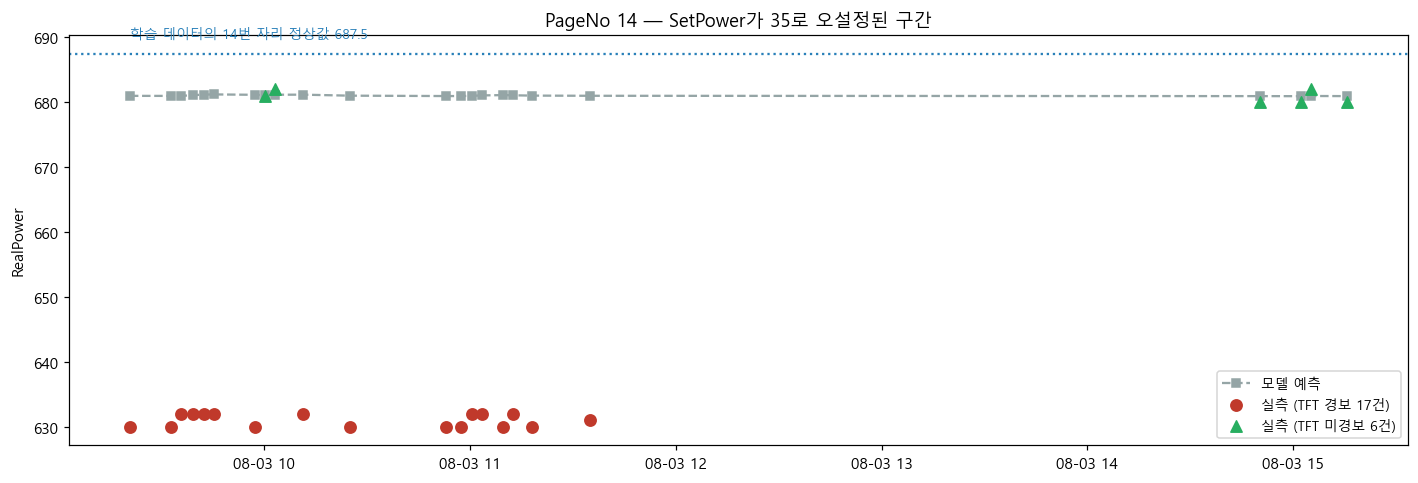

In [17]:
p14 = r3[r3.PageNo==14].copy()
p14['t'] = pd.to_datetime(p14['WorkingTime'])

fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(p14['t'], p14['pred'], 's--', ms=5, color='#95a5a6', label='모델 예측')
m_hit  = p14['tft']==1
ax.scatter(p14.loc[m_hit,'t'],  p14.loc[m_hit,'RealPower'],  s=55, color='#c0392b',
           label=f'실측 (TFT 경보 {m_hit.sum()}건)', zorder=5)
ax.scatter(p14.loc[~m_hit,'t'], p14.loc[~m_hit,'RealPower'], s=55, color='#27ae60',
           marker='^', label=f'실측 (TFT 미경보 {(~m_hit).sum()}건)', zorder=5)
ax.axhline(687.5, ls=':', color='#2980b9')
ax.text(p14['t'].min(), 690, '학습 데이터의 14번 자리 정상값 687.5', fontsize=9, color='#2980b9')
ax.set_ylabel('RealPower'); ax.set_title('PageNo 14 — SetPower가 35로 오설정된 구간')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

**발견 ⑦  TFT는 라벨을 완벽히 재현했지만 설정 이상은 놓쳤다**

```
        label=0  label=1              rule=0  rule=1
tft=0      862       0        tft=0     860       2   ← 여기
tft=1        0      17        tft=1       0      17
```

**TFT 경보 17건** — 전부 PageNo 14 / SetPower 35 / RealPower 630~632
예측 681 근처, 잔차 −49~−51, **z −40.7 ~ −42.5**

**규칙 A는 잡고 TFT는 놓친 2건**

| PageNo | SetPower | RealPower | 예측 | 잔차 | z | label |
|---|---|---|---|---|---|---|
| 14 | **35** | 681 | 681.08 | −0.08 | −0.41 | 0 |
| 14 | **35** | 682 | 681.16 | +0.84 | +0.35 | 0 |

**모델이 이상 상태에 적응했다.**
인코더 78 = 두 사이클인데, 그 구간이 **이미 SetPower 35로 돌던 중**이었다.
모델은 "이 자리는 요즘 681이 나오네"를 학습해버렸다.

**핵심 차이**

| | 보는 것 | 그 2건 |
|---|---|---|
| 라벨 | RealPower 결과 | 정상으로 표시 |
| TFT | RealPower 예측 잔차 | 안 잡음 |
| **규칙 A** | **SetPower 설정** | **잡음** |

TFT가 라벨을 완벽히 재현한 것은 **둘 다 결과값을 보기 때문**이지
현장 기준으로 더 낫다는 뜻이 아니다. 설정이 35로 틀린 상태로 계속 돌고 있었고,
출력이 우연히 정상 범위로 나왔을 뿐이다.

## 12. ng4 극단값 확인

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


 PageNo  SetPower  RealPower        pred     residual            z              WorkingTime
     12        83        0.0 1727.680054 -1727.680054 -1422.790039  2022-08-03 16:36:22.321
     29        83        0.0 1724.349976 -1724.349976 -1420.040039  2022-08-03 16:37:33.153
     21        83        0.0 1723.290039 -1723.290039 -1419.170044  2022-08-03 16:37:05.575
     10        83        0.0 1722.579956 -1722.579956 -1418.589966  2022-08-03 16:36:16.337
     27        83        0.0 1722.530029 -1722.530029 -1418.540039  2022-08-03 16:37:27.017
     23        83        0.0 1722.479980 -1722.479980 -1418.500000  2022-08-03 16:37:11.673
      6        83        0.0 1721.719971 -1721.719971 -1417.880005  2022-08-03 16:36:01.189
      8        83        0.0 1719.430054 -1719.430054 -1415.989990  2022-08-03 16:36:10.363
      4        83        0.0 1719.140015 -1719.140015 -1415.750000  2022-08-03 16:35:55.107
     19        83        0.0 1716.170044 -1716.170044 -1413.310059  2022-08-03 1

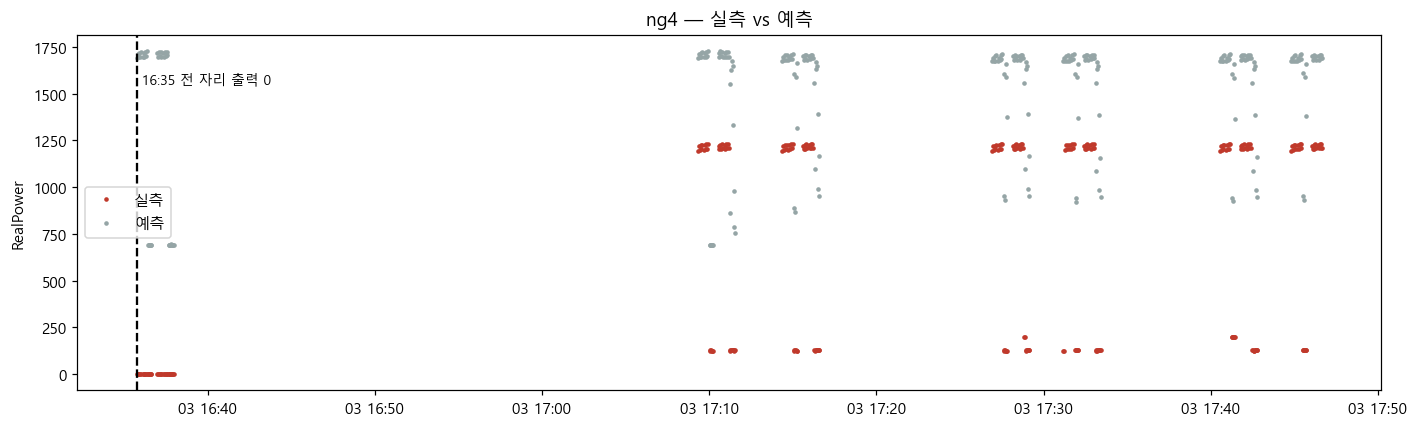

In [18]:
model = TFT.load_from_checkpoint(find_best('B'))
r4 = one_step_residuals(NG4, DS['B'], model)
r4['z'] = (r4['residual']-mu)/sd
idx4 = r4['time_idx'].values
m4 = NG4.set_index('time_idx').loc[idx4, ['PageNo','SetPower','RealPower','WorkingTime']]
r4 = pd.concat([r4.reset_index(drop=True), m4.reset_index(drop=True)], axis=1)

top = r4.reindex(r4['z'].abs().sort_values(ascending=False).index).head(10)
print(top[['PageNo','SetPower','RealPower','pred','residual','z','WorkingTime']].round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(13,4))
t4 = pd.to_datetime(r4['WorkingTime'])
ax.plot(t4, r4['actual'], '.', ms=4, label='실측', color='#c0392b')
ax.plot(t4, r4['pred'],   '.', ms=4, label='예측', color='#95a5a6')
ax.axvline(pd.Timestamp('2022-08-03 16:35:45'), ls='--', color='k')
ax.text(pd.Timestamp('2022-08-03 16:35:45'), r4['pred'].max()*0.9,
        ' 16:35 전 자리 출력 0', fontsize=9)
ax.set_ylabel('RealPower'); ax.set_title('ng4 — 실측 vs 예측'); ax.legend()
plt.tight_layout(); plt.show()

del model; gc.collect(); torch.cuda.empty_cache()

**결과**

|z| 상위 10건이 전부 **SetPower 83 / RealPower 0**이다 (16:35:55 ~ 16:37:33).
최대는 PageNo 12, 예측 1727.68, 잔차 −1727.68, **z = −1422.79**.

16시 35분 사이클에서 **39자리 전부 미발광**이었던 구간이다.
모델이 1727을 예측했는데 0이 나왔으므로 잔차가 그대로 −1727이 된다.

## 13. 결론

### 실험 결과

| 조건 | 인코더 | 공변량 | 파라미터 | best val_loss |
|---|---|---|---|---|
| A-20 | 20 | 없음 | 59.0k | **139.1003** |
| A | **78** | 없음 | 59.0k | **8.4783** |
| **B** | 78 | **PageNo** | 59.9k | **1.2371** |
| C | 78 | PageNo+SetPower+GateOnTime | 60.8k | 3.0473 |

```
인코더 20 → 78        139.10 → 8.48     16.4배
공변량 PageNo 추가      8.48 → 1.24      6.9배
공변량 3개            1.24 → 3.05      악화 + 추론 불가
```

### 탐지 평가 (채택 threshold: A 2.44 / B 5.71)

| 모델 | ok1 | ok2 | ng3 | ng4 |
|---|---|---|---|---|
| A | 0건 | 2건 (0.12%) | F1 0.9189 (정밀도 0.85) | F1 1.0000 |
| **B** | **0건** | **0건** | **F1 1.0000** | **F1 1.0000** |

**TFT B는 4파일 4,530행에서 오탐·미탐 0건이다.**

### 판정 여유

| 파일 | 최대 \|z\| |
|---|---|
| ok1 (정상) | 4.36 |
| ok2 (정상) | 5.11 |
| ng3 (이상) | 42.45 |
| ng4 (이상) | 1422.79 |

**정상 최대 5.11, 이상 최소 40.68.** 그 사이가 비어 있다.
백분위수 민감도 분석(§10-1)에서 threshold 5.71~8.27 전 구간 결과가 동일함을 확인했다.

### 결론

**1. 데이터 구조가 하이퍼파라미터를 결정한다.**
인코더 78은 탐색으로 찾은 값이 아니다. 39주기를 확인하고 그 2배로 설정했다.
가이드북과 조원은 20을 썼고, 그것이 val_loss 139의 원인이었다.

**2. 변수를 더 넣는다고 좋아지지 않는다.**
누수 검사에서 PageNo가 나머지 설정을 완전 결정함을 확인했다.
새 정보가 0인데 파라미터만 늘어 성능이 2.5배 악화됐고,
ng3의 SetPower=35에서는 미지 카테고리로 **추론 자체가 실패**했다.

**3. 예측 성능과 탐지 성능은 threshold가 연결한다.**
1차 평가(검증구간 threshold)에서 예측이 7배 정확한 B가 탐지 F1은 절반이었다(0.49 vs 0.27).
2차 평가(학습전체 threshold)에서 순위가 재역전됐다(0.92 vs 1.00).
→ **"예측이 정확해지면 탐지가 나빠진다"가 아니라
"예측이 정확해지면 threshold를 그 모델에 맞춰 다시 잡아야 한다"가 맞다.**

**4. 모델과 규칙은 서로 다른 것을 본다.**
ng3에서 규칙 A는 잡고 TFT는 놓친 2건이 있다(PageNo 14, SetPower 35, RealPower 681/682).
인코더 78이 이미 이상 상태여서 모델이 681을 정상으로 학습했다(잔차 −0.08).
**이상이 인코더 길이보다 오래 지속되면 모델은 적응한다.**
규칙은 문맥을 보지 않으므로 지속 여부와 무관하게 잡는다.

### 한계

| 항목 | 내용 | 상태 |
|---|---|---|
| 이상 사건 수 | ng3 1건, ng4 1건 = **사실상 2개**. 일반화 근거 제한 | 해소 불가 |
| 규칙 A 도출 순서 | 논리는 학습 데이터만으로 성립하나 **실제로는 테스트셋을 먼저 봄** | 기록으로만 |
| threshold 변경 시점 | 구간 변경 이유는 결과와 무관하나 **시점은 1차 평가 후** | 기록으로만 |
| TFT 이상 적응 | 인코더 구간이 이미 이상이면 정상으로 학습 (ng3 2건) | 규칙 병용 |
| 백분위수 99.9 | 99.9~100.0 전 구간 결과 동일 확인 | **해소됨** |
| 판정 기준 ±1 | seed 반복 대신 epoch 간 변동으로 갈음 | 미해소 |
| A-20 결과 | 별도 실행값을 표에 인용 | 재현 필요 |